# Tugas Analisis Numerik
**Nama:** Safira Wahyu Rosiana

**NPM:** 25083010026  

**Kelas:** A083

**LINK GITHUB:** https://github.com/25083010026-tech/Tugas-Analisis-Numerik-Gerai-Donat-Safira-Wahyu-Rosiana/blob/main/25083010026_Safira_Wahyu_Rosiana_Tugas_Analisis_Numerik.ipynb

Data: `sintesis_data_donat_harian.csv`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/jendralhxr/metnummatdis/main/sintesis_data_donat_harian.csv"
try:
    df = pd.read_csv(URL)
except Exception:
    df = pd.read_csv("sintesis_data_donat_harian.csv")   # cadangan bila offline

df.columns = ["tanggal","gerai","harga","qty","revenue","biaya_var","fixed_cost","balance"]
print(df.shape, "| nilai kosong:", df.isna().sum().sum())
df.head()

(450, 8) | nilai kosong: 0


,tanggal,gerai,harga,qty,revenue,biaya_var,fixed_cost,balance
0,2026-01-01,Gerai A,25000,87,2175000,739500,1683333,-247833
1,2026-01-02,Gerai A,25000,81,2025000,688500,1683333,-346833
2,2026-01-03,Gerai A,25000,110,2750000,935000,1683333,131667
3,2026-01-04,Gerai A,25000,119,2975000,1011500,1683333,280167
4,2026-01-05,Gerai A,25000,94,2350000,799000,1683333,-132333


In [2]:
# Ringkasan per gerai
ringkas = df.groupby("gerai").agg(
    harga=("harga","first"), qty_min=("qty","min"), qty_max=("qty","max"),
    qty_rata2=("qty","mean"), fixed_cost=("fixed_cost","first"),
    hari_rugi=("balance", lambda s:(s<0).sum()))
ringkas["biaya_var_per_unit"] = df.groupby("gerai").apply(lambda g:(g.biaya_var/g.qty).mean())
ringkas.round(1)

/tmp/ipykernel_982/3641850274.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ringkas["biaya_var_per_unit"] = df.groupby("gerai").apply(lambda g:(g.biaya_var/g.qty).mean())


,harga,qty_min,qty_max,qty_rata2,fixed_cost,hari_rugi,biaya_var_per_unit
gerai,,,,,,,
Gerai A,25000,81,131,99.1,1683333,59,8500.0
Gerai B,8000,435,710,527.5,733333,0,4160.0
Gerai C,11000,220,522,328.9,1733333,28,4840.0
Gerai D,20000,103,223,149.8,2666666,86,7200.0
Gerai E,15000,153,332,226.6,800000,0,6300.0


**Catatan data:** harga jual dan fixed cost tiap gerai konstan, sehingga `revenue = harga × qty` dan
`biaya variabel = biaya per unit × qty`.

---
## (1) — Plot jumlah penjualan vs revenue

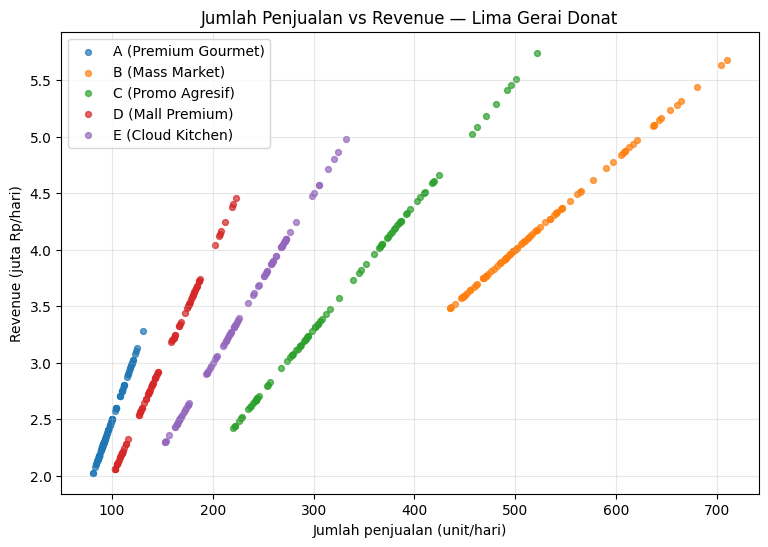

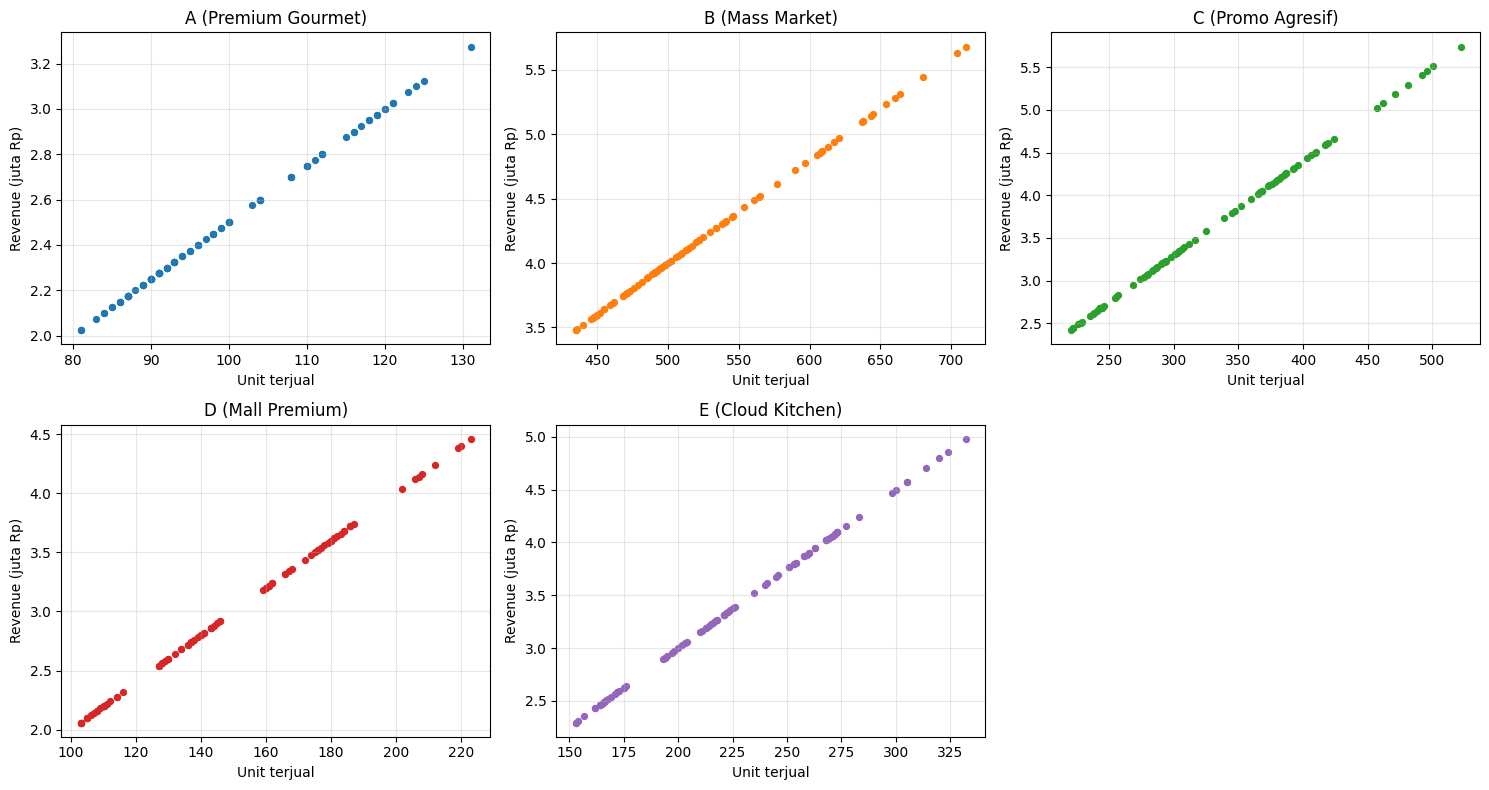

In [3]:
warna = {"Gerai A":"tab:blue","Gerai B":"tab:orange","Gerai C":"tab:green","Gerai D":"tab:red","Gerai E":"tab:purple"}
namagerai = {"Gerai A":"A (Premium Gourmet)","Gerai B":"B (Mass Market)","Gerai C":"C (Promo Agresif)",
             "Gerai D":"D (Mall Premium)","Gerai E":"E (Cloud Kitchen)"}
daftar = sorted(df.gerai.unique())

# (a) semua gerai dalam satu grafik
plt.figure(figsize=(9,6))
for g in daftar:
    d = df[df.gerai==g]
    plt.scatter(d.qty, d.revenue/1e6, s=18, alpha=.7, c=warna[g], label=namagerai[g])
plt.xlabel("Jumlah penjualan (unit/hari)"); plt.ylabel("Revenue (juta Rp/hari)")
plt.title("Jumlah Penjualan vs Revenue — Lima Gerai Donat")
plt.grid(alpha=.3); plt.legend(); plt.show()

# (b) panel terpisah per gerai (skala tiap gerai berbeda jauh)
fig, ax = plt.subplots(2,3, figsize=(15,8)); ax = ax.ravel()
for i,g in enumerate(daftar):
    d = df[df.gerai==g]
    ax[i].scatter(d.qty, d.revenue/1e6, s=18, c=warna[g])
    ax[i].set_title(namagerai[g]); ax[i].set_xlabel("Unit terjual"); ax[i].set_ylabel("Revenue (juta Rp)")
    ax[i].grid(alpha=.3)
ax[5].axis("off"); plt.tight_layout(); plt.show()

**Jawaban SOAL 1:** Pada kelima gerai, titik-titik data membentuk garis lurus yang melewati titik asal.
Kemiringannya berbeda-beda sesuai harga jual: Gerai A paling curam (Rp25.000/unit), Gerai B paling landai (Rp8.000/unit),
tetapi B menjual unit terbanyak (435–710/hari), sedangkan A hanya 81–131/hari.

---
## (2) — Regresi tren revenue terhadap volume penjualan

Tiga model dibandingkan untuk tiap gerai:
1. **Linear:** $R(q)=a\,q+b$
2. **Polinomial derajat 2:** $R(q)=c_2 q^2 + c_1 q + c_0$
3. **Eksponen:** $R(q)=A\,e^{kq}$ (dilinearkan dengan $\ln R = \ln A + kq$)

Kriteria pemilihan: $R^2$ dan RMSE pada skala Rupiah.

In [4]:
def r2(y, yh): return 1 - np.sum((y-yh)**2)/np.sum((y-y.mean())**2)
def rmse(y, yh): return np.sqrt(np.mean((y-yh)**2))

hasil, model = [], {}
for g in daftar:
    d = df[df.gerai==g]; q, R = d.qty.values.astype(float), d.revenue.values.astype(float)
    p1 = np.polyfit(q, R, 1)
    p2 = np.polyfit(q, R, 2)
    k, lnA = np.polyfit(q, np.log(R), 1); A = np.exp(lnA)
    yh = {"Linear":np.polyval(p1,q), "Polinomial-2":np.polyval(p2,q), "Eksponen":A*np.exp(k*q)}
    for nama, y in yh.items():
        hasil.append([g, nama, r2(R,y), rmse(R,y)])
    model[g] = dict(p1=p1, p2=p2, A=A, k=k)

tabel = pd.DataFrame(hasil, columns=["Gerai","Model","R2","RMSE (Rp)"])
pd.options.display.float_format = "{:,.6f}".format
tabel.pivot(index="Gerai", columns="Model", values="R2")

Model,Eksponen,Linear,Polinomial-2
Gerai,,,
Gerai A,0.996796,1.000000,1.000000
Gerai B,0.995544,1.000000,1.000000
Gerai C,0.982447,1.000000,1.000000
Gerai D,0.985756,1.000000,1.000000
Gerai E,0.986544,1.000000,1.000000


In [ ]:
pd.options.display.float_format = "{:,.2f}".format
tabel.pivot(index="Gerai", columns="Model", values="RMSE (Rp)")

Model,Eksponen,Linear,Polinomial-2
Gerai,,,
Gerai A,"17,582.80",0.00,0.00
Gerai B,"36,430.07",0.00,0.00
Gerai C,"111,764.48",0.00,0.00
Gerai D,"78,434.38",0.00,0.00
Gerai E,"80,948.45",0.00,0.00


In [5]:
# Koefisien regresi linear terpilih: R(q) = a*q + b
lin = pd.DataFrame({g:{"a (slope, Rp/unit)":model[g]["p1"][0], "b (intersep, Rp)":model[g]["p1"][1],
                       "harga jual asli":df[df.gerai==g].harga.iloc[0]} for g in daftar}).T
lin

,"a (slope, Rp/unit)","b (intersep, Rp)",harga jual asli
Gerai A,"25,000.000000",-0.000000,"25,000.000000"
Gerai B,"8,000.000000",-0.000000,"8,000.000000"
Gerai C,"11,000.000000",0.000000,"11,000.000000"
Gerai D,"20,000.000000",-0.000000,"20,000.000000"
Gerai E,"15,000.000000",0.000000,"15,000.000000"


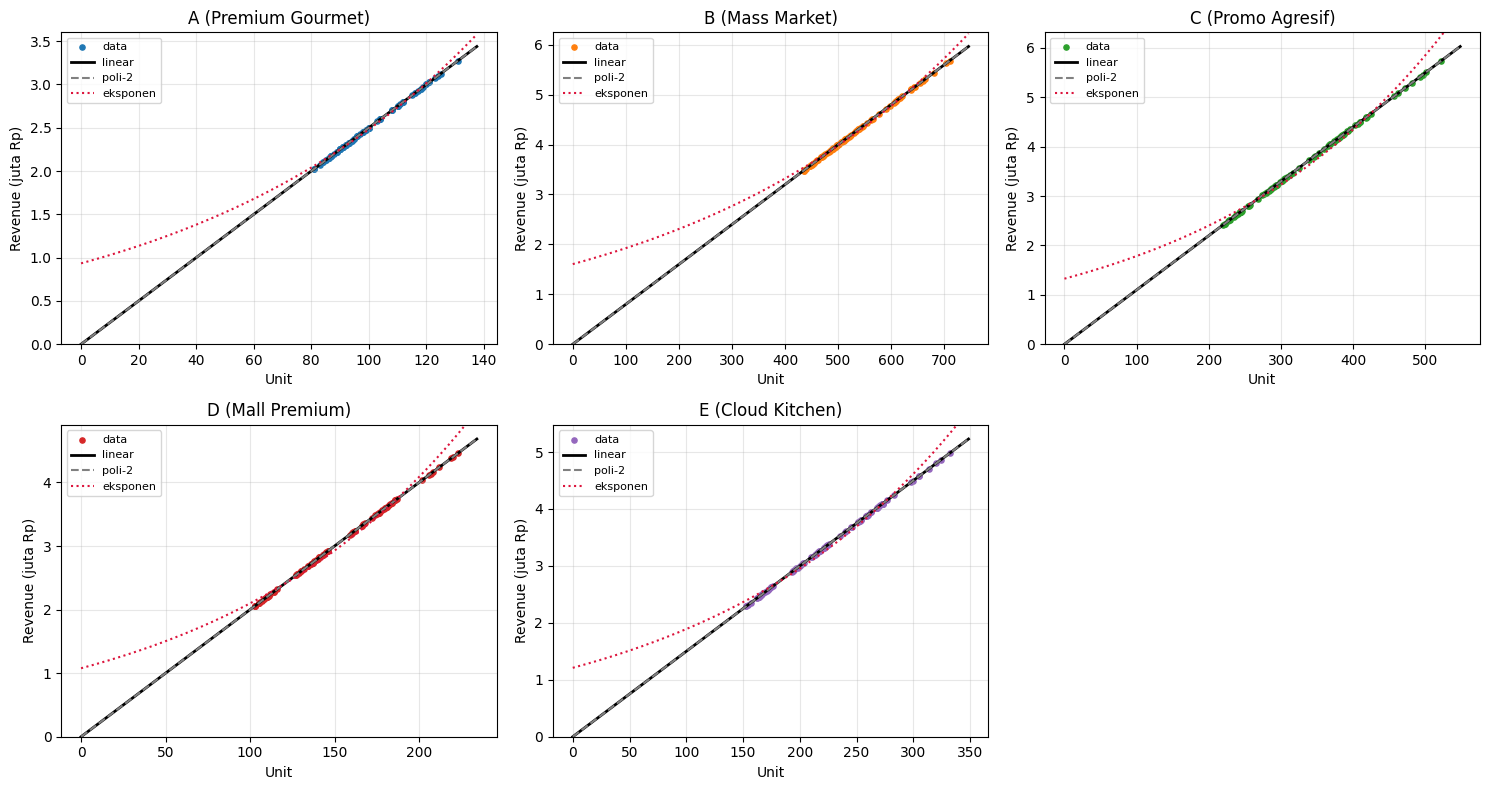

In [6]:
fig, ax = plt.subplots(2,3, figsize=(15,8)); ax = ax.ravel()
for i,g in enumerate(daftar):
    d = df[df.gerai==g]; m = model[g]
    qq = np.linspace(0, d.qty.max()*1.05, 200)
    ax[i].scatter(d.qty, d.revenue/1e6, s=14, c=warna[g], label="data")
    ax[i].plot(qq, np.polyval(m["p1"],qq)/1e6, "k-", lw=2, label="linear")
    ax[i].plot(qq, np.polyval(m["p2"],qq)/1e6, "--", c="gray", label="poli-2")
    ax[i].plot(qq, m["A"]*np.exp(m["k"]*qq)/1e6, ":", c="crimson", label="eksponen")
    ax[i].set_ylim(0, d.revenue.max()*1.1/1e6)
    ax[i].set_title(namagerai[g]); ax[i].set_xlabel("Unit"); ax[i].set_ylabel("Revenue (juta Rp)")
    ax[i].grid(alpha=.3); ax[i].legend(fontsize=8)
ax[5].axis("off"); plt.tight_layout(); plt.show()

**Jawaban soal 2:** Model linear dipilih untuk semua gerai. $R^2 = 1$ dan RMSE ≈ 0, dengan
slope sama persis dengan harga jual dan intersep ≈ 0. Ini wajar karena revenue = harga × unit. Polinomial derajat 2 tidak
memperbaiki apa-apa (koefisien kuadratnya ≈ 0, hanya menambah parameter). Model eksponen paling buruk,
karena pertumbuhan revenue terhadap volume tidak eksponensial, melainkan proporsional.

---
## (3) — Volume penjualan pada breakeven point

**Breakeven** terjadi saat revenue = biaya total: $f(q)=R(q)-C(q)=0$, dengan

- $R(q)$ dari regresi linear revenue (butir 2),
- $C(q) = (\text{regresi linear biaya variabel})(q) + \text{fixed cost harian}$.

Akar $f(q)=0$ dicari secara numerik dengan metode Bisection, Newton-Raphson, dan Secant, lalu
dicocokkan dengan solusi analitik $q^*=\dfrac{b_R - b_C - FC}{a_C - a_R}$.

In [7]:
# Regresi linear biaya variabel & fixed cost tiap gerai
fungsi = {}
for g in daftar:
    d = df[df.gerai==g]
    aR, bR = model[g]["p1"]
    aC, bC = np.polyfit(d.qty.values.astype(float), d.biaya_var.values.astype(float), 1)
    FC = d.fixed_cost.mean()
    fungsi[g] = dict(aR=aR, bR=bR, aC=aC, bC=bC+FC, FC=FC)   # C(q) = aC*q + (bC + FC)

pd.DataFrame(fungsi).T.rename(columns={"aR":"slope revenue","bR":"intersep revenue",
    "aC":"slope biaya var/unit","bC":"intersep biaya total","FC":"fixed cost"})

,slope revenue,intersep revenue,slope biaya var/unit,intersep biaya total,fixed cost
Gerai A,"25,000.000000",-0.000000,"8,500.000000","1,683,333.000000","1,683,333.000000"
Gerai B,"8,000.000000",-0.000000,"4,160.000000","733,333.000000","733,333.000000"
Gerai C,"11,000.000000",0.000000,"4,840.000000","1,733,333.000000","1,733,333.000000"
Gerai D,"20,000.000000",-0.000000,"7,200.000000","2,666,666.000000","2,666,666.000000"
Gerai E,"15,000.000000",0.000000,"6,300.000000","800,000.000000","800,000.000000"


In [8]:
def bisection(f, a, b, tol=1e-8, maks=200):
    fa, fb = f(a), f(b)
    assert fa*fb < 0, "akar tidak terkurung di [a,b]"
    for i in range(1, maks+1):
        c = (a+b)/2; fc = f(c)
        if abs(fc) < tol or (b-a)/2 < tol: return c, i
        if fa*fc < 0: b, fb = c, fc
        else: a, fa = c, fc
    return c, maks

def newton(f, df_, x0, tol=1e-8, maks=100):
    x = x0
    for i in range(1, maks+1):
        xn = x - f(x)/df_(x)
        if abs(xn-x) < tol: return xn, i
        x = xn
    return x, maks

def secant(f, x0, x1, tol=1e-8, maks=100):
    for i in range(1, maks+1):
        x2 = x1 - f(x1)*(x1-x0)/(f(x1)-f(x0))
        if abs(x2-x1) < tol: return x2, i
        x0, x1 = x1, x2
    return x1, maks

baris = []
for g in daftar:
    p = fungsi[g]
    f  = lambda q, p=p: (p["aR"]-p["aC"])*q + (p["bR"]-p["bC"])
    df_ = lambda q, p=p: (p["aR"]-p["aC"])
    q_bis, it_b = bisection(f, 0, 1000)
    q_new, it_n = newton(f, df_, 50)
    q_sec, it_s = secant(f, 0, 1000)
    q_ana = (p["bC"]-p["bR"])/(p["aR"]-p["aC"])
    rata = df[df.gerai==g].qty.mean()
    baris.append([g, q_bis, it_b, q_new, it_n, q_sec, it_s, q_ana, int(np.ceil(q_ana)), rata])

be = pd.DataFrame(baris, columns=["Gerai","Bisection","iter","Newton","iter ","Secant","iter  ",
                                  "Analitik","BEP (dibulatkan ke atas)","Rata-rata qty aktual"]).set_index("Gerai")
pd.options.display.float_format = "{:,.4f}".format
be

,Bisection,iter,Newton,iter,Secant,iter,Analitik,BEP (dibulatkan ke atas),Rata-rata qty aktual
Gerai,,,,,,,,,
Gerai A,102.0202,37,102.0202,2,102.0202,2,102.0202,103,99.1000
Gerai B,190.9721,37,190.9721,2,190.9721,2,190.9721,191,527.5000
Gerai C,281.3852,37,281.3852,2,281.3852,2,281.3852,282,328.9333
Gerai D,208.3333,37,208.3333,2,208.3333,2,208.3333,209,149.8333
Gerai E,91.9540,37,91.9540,2,91.9540,2,91.9540,92,226.6444


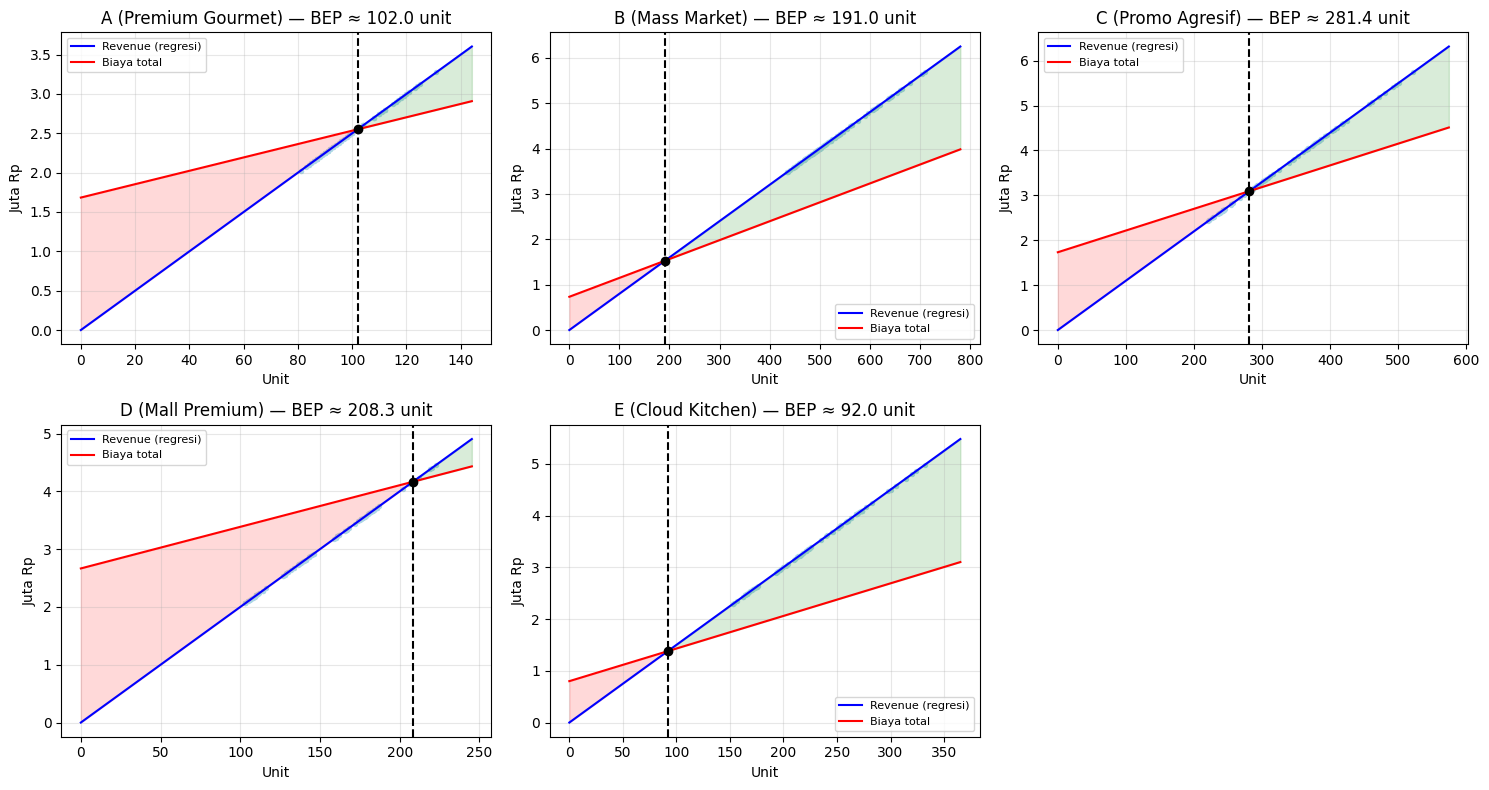

In [9]:
fig, ax = plt.subplots(2,3, figsize=(15,8)); ax = ax.ravel()
for i,g in enumerate(daftar):
    p = fungsi[g]; d = df[df.gerai==g]
    qq = np.linspace(0, d.qty.max()*1.1, 200)
    R = p["aR"]*qq + p["bR"]; Cc = p["aC"]*qq + p["bC"]
    q0 = be.loc[g,"Analitik"]
    ax[i].plot(qq, R/1e6, "b-", label="Revenue (regresi)")
    ax[i].plot(qq, Cc/1e6, "r-", label="Biaya total")
    ax[i].scatter(d.qty, d.revenue/1e6, s=8, c="lightblue")
    ax[i].axvline(q0, c="k", ls="--"); ax[i].plot(q0, (p["aR"]*q0+p["bR"])/1e6, "ko")
    ax[i].fill_between(qq, R/1e6, Cc/1e6, where=R>=Cc, color="green", alpha=.15)
    ax[i].fill_between(qq, R/1e6, Cc/1e6, where=R<Cc, color="red", alpha=.15)
    ax[i].set_title(f"{namagerai[g]} — BEP ≈ {q0:.1f} unit"); ax[i].set_xlabel("Unit"); ax[i].set_ylabel("Juta Rp")
    ax[i].grid(alpha=.3); ax[i].legend(fontsize=8)
ax[5].axis("off"); plt.tight_layout(); plt.show()

In [10]:
# Validasi terhadap data: berapa persen hari yang melewati BEP dan benar-benar untung?
cek = []
for g in daftar:
    d = df[df.gerai==g]; q0 = be.loc[g,"Analitik"]
    cek.append([g, round(q0,1), (d.qty>=np.ceil(q0)).mean()*100, (d.balance>0).mean()*100])
pd.DataFrame(cek, columns=["Gerai","BEP (unit)","% hari qty ≥ BEP","% hari balance > 0 (data asli)"]).set_index("Gerai").round(1)

,BEP (unit),% hari qty ≥ BEP,% hari balance > 0 (data asli)
Gerai,,,
Gerai A,102.0000,34.4000,34.4000
Gerai B,191.0000,100.0000,100.0000
Gerai C,281.4000,68.9000,68.9000
Gerai D,208.3000,4.4000,4.4000
Gerai E,92.0000,100.0000,100.0000


### Kesimpulan

| Gerai | Strategi | Breakeven (unit/hari) |
|---|---|---|
| A | Premium Gourmet | ≈ 102,0 → **103** |
| B | Mass Market Volume | ≈ 191,0 → **191** |
| C | Promo Agresif | ≈ 281,4 → **282** |
| D | Mall Premium Flagship | ≈ 208,3 → **209** |
| E | Cloud Kitchen (komisi 18%) | ≈ 92,0 → **92** |

- Ketiga metode numerik (Bisection, Newton, Secant) konvergen ke akar yang sama dengan solusi analitik. Karena $f(q)$ linear,
  Newton dan Secant konvergen dalam 1–2 iterasi, sedangkan Bisection butuh puluhan iterasi.
- Gerai B dan E jauh di atas breakeven: volume aktual rata-rata 527 dan 227 unit/hari, dan 100% hari untung.
- Gerai A rata-rata menjual 99 unit/hari, tepat di bawah BEP 103, sehingga rugi di 59 dari 90 hari.
- Gerai C rata-rata 329 unit/hari (BEP 282), untung di sekitar 69% hari. Fixed cost iklan yang besar dengan margin per unit kecil membuatnya sensitif terhadap volume.
- Gerai D (sewa mall) butuh ≥209 unit/hari, padahal rata-rata hanya 150; rugi di 86 dari 90 hari dan hanya 4,4% hari yang melewati BEP.
- Pengecekan pada data asli (sel terakhir) cocok: persentase hari qty ≥ BEP sama dengan persentase hari balance > 0.
- Hasil BEP dibulatkan ke atas karena unit donat berupa bilangan bulat.
- Kualitas hasil bergantung pada asumsi data: harga dan fixed cost konstan sehingga model linear sempurna. Pada data riil dengan diskon atau
  harga yang berubah, hubungan bisa nonlinear dan metode akar seperti Newton/Secant menjadi lebih relevan.